# Adım 1

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri okuma
df = pd.read_csv('/Users/nurefsandolas/Projects/predictive_maintenance_project/data/predictive_maintenance.csv')

# Verinin ilk 5 satırı
print(df.head())

# Verinin genel yapısı (sütun tipleri ve eksik değer kontrolü)
df.info()

  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            298.1                308.6              1551    42.8   
1    L            298.2                308.7              1408    46.3   
2    L            298.1                308.5              1498    49.4   
3    L            298.2                308.6              1433    39.5   
4    L            298.2                308.7              1408    40.0   

   Tool wear  Machine failure  TWF  HDF  PWF  OSF  RNF  
0          0                0    0    0    0    0    0  
1          3                0    0    0    0    0    0  
2          5                0    0    0    0    0    0  
3          7                0    0    0    0    0    0  
4          9                0    0    0    0    0    0  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type       

--- Arıza Dağılımı ---
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


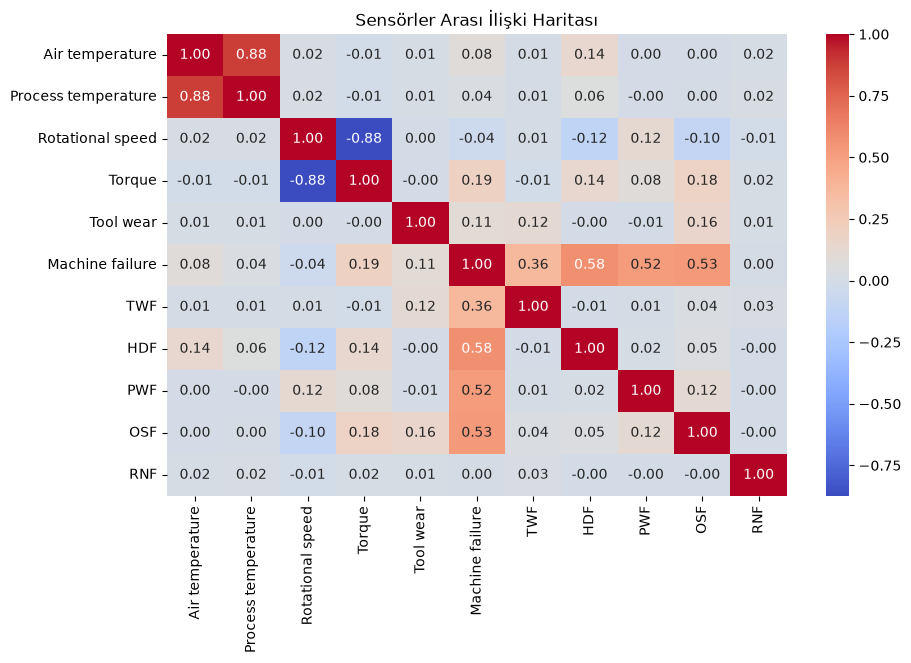

In [ ]:
# 1. Hata (Failure) oranlarını kontrol
print("--- Arıza Dağılımı ---")
print(df['Machine failure'].value_counts(normalize=True))

# 2. Korelasyon Matrisi (Hangi sensörler birbirini tetikliyor?)
# 'Type' sütunu kategorik olduğu için onu şimdilik hariç tutuyoruz
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['Type']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensörler Arası İlişki Haritası")
plt.show()

In [ ]:
# Yeni feature oluşturma
df['temp_diff'] = df['Process temperature'] - df['Air temperature']
df['power'] = df['Torque'] * df['Rotational speed']
df['wear_x_torque'] = df['Tool wear'] * df['Torque']

# Yeni değişkenlerin Machine failure ile korelasyonu
print(df[['Machine failure', 'temp_diff', 'power', 'wear_x_torque']].corr())

                 Machine failure  temp_diff     power  wear_x_torque
Machine failure         1.000000  -0.111676  0.176039       0.190427
temp_diff              -0.111676   1.000000  0.006694      -0.005051
power                   0.176039   0.006694  1.000000       0.368842
wear_x_torque           0.190427  -0.005051  0.368842       1.000000


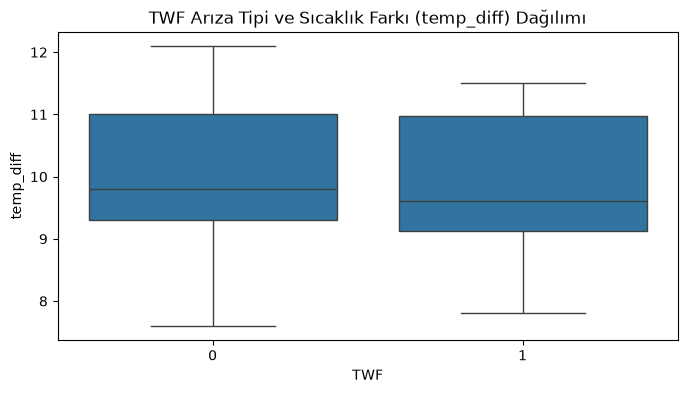

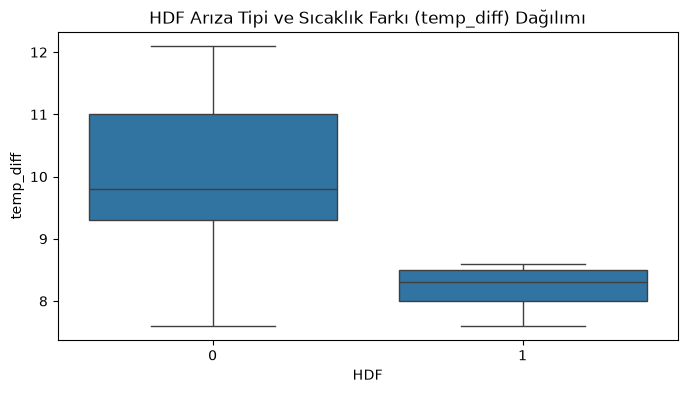

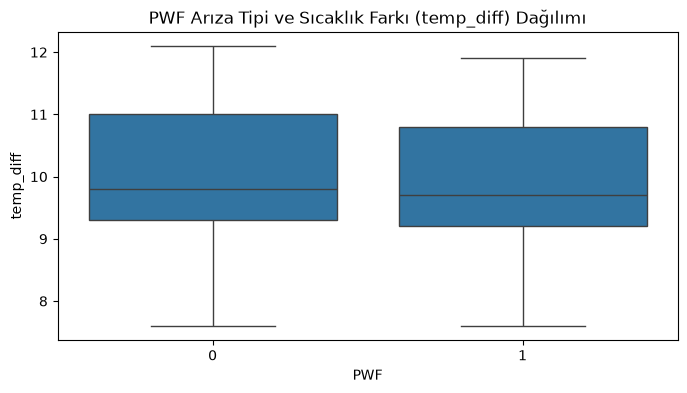

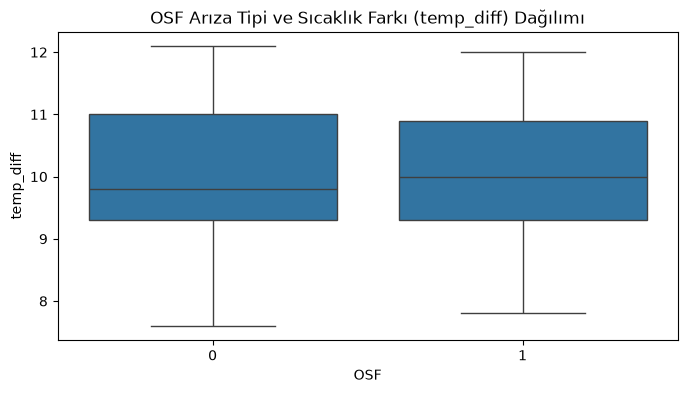

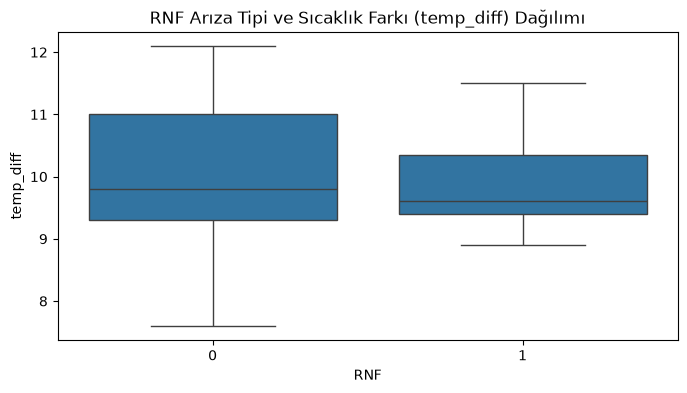

In [ ]:
# Hangi failure tiplerinin arıza ile en çok ilişkili olduğunu görselleştirme
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in failure_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], y=df['temp_diff'])
    plt.title(f"{col} Arıza Tipi ve Sıcaklık Farkı (temp_diff) Dağılımı")
    plt.show()

# Adım 2

In [10]:
print(df.columns.tolist())

['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_diff', 'power', 'wear_x_torque']


In [11]:
# Target (tahmin edeceğimiz değişken)
y = df["Machine failure"]

# Feature'lar (modele verilecek bilgiler)
X = df.drop(
    columns=[
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X.head()

X boyutu: (10000, 9)
y boyutu: (10000,)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


In [12]:
# Type sütununu One-Hot Encoding ile sayısallaştır
X = pd.get_dummies(X, columns=["Type"], dtype=int)

print("Yeni X boyutu:", X.shape)
X.head()

Yeni X boyutu: (10000, 11)


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0,0,0,1
1,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9,0,1,0
2,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0,0,1,0
3,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5,0,1,0
4,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0,0,1,0


In [13]:
from sklearn.model_selection import train_test_split

# Adım 3

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 11)
Test: (2000, 11)


In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain dağılımı:")
print(y_train.value_counts())

print("\nTest dağılımı:")
print(y_test.value_counts())

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)

Train dağılımı:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test dağılımı:
Machine failure
0    1932
1      68
Name: count, dtype: int64


# Adım 4
(Random Forest)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)

# İlk 10 tahmin
print("İlk 10 tahmin:")
print(y_pred[:10])

print("\nİlk 10 gerçek değer:")
print(y_test.iloc[:10].values)

İlk 10 tahmin:
[0 0 0 0 0 0 0 0 0 0]

İlk 10 gerçek değer:
[0 0 0 0 0 0 0 0 0 0]


In [19]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9915

Confusion Matrix:
[[1930    2]
 [  15   53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.78      0.86        68

    accuracy                           0.99      2000
   macro avg       0.98      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



# Adım 5
(class_weight="balanced")

In [20]:
from sklearn.ensemble import RandomForestClassifier

balanced_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_balanced))

print(classification_report(y_test, y_pred_balanced))

[[1930    2]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.97      0.82      0.89        68

    accuracy                           0.99      2000
   macro avg       0.98      0.91      0.94      2000
weighted avg       0.99      0.99      0.99      2000



### Model Comparison

Random Forest modeli başlangıçta %78 Recall elde etti. 
Veri setindeki sınıf dengesizliği nedeniyle `class_weight="balanced"` parametresi kullanılarak model yeniden eğitildi.

Sonuç olarak:

- Recall %78'den %82'ye yükseldi.
- False Negative sayısı 15'ten 12'ye düştü.
- Precision korunurken F1 skoru arttı.

Bu nedenle sonraki analizlerde balanced model kullanılacaktır.

In [22]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": balanced_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Rotational speed,0.202056
3,Torque,0.190545
6,power,0.179067
4,Tool wear,0.138223
7,wear_x_torque,0.115255
5,temp_diff,0.085796
0,Air temperature,0.050115
1,Process temperature,0.027966
10,Type_M,0.004836
9,Type_L,0.003933


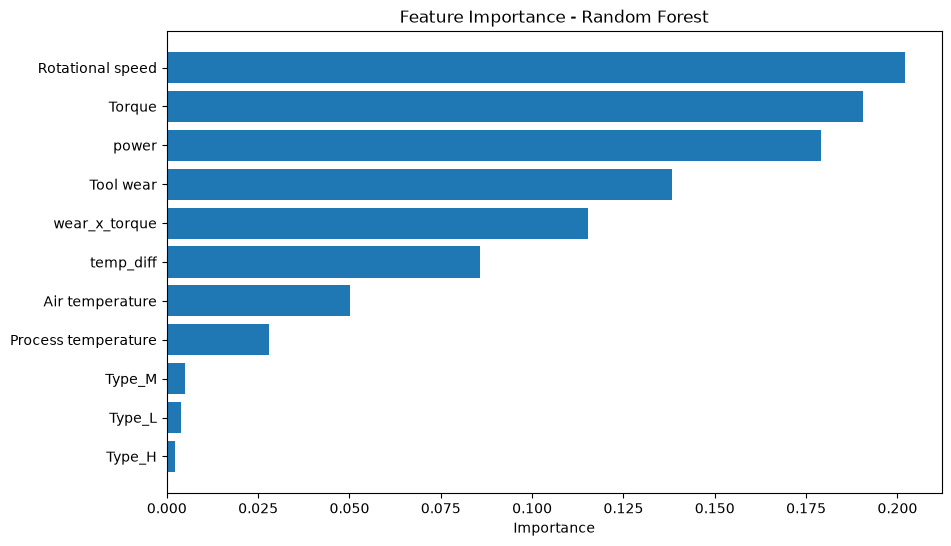

In [23]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.show()

# Adım 6

In [24]:
# Her sınıf için olasılık tahmini
y_prob = balanced_model.predict_proba(X_test)

print(y_prob[:5])

[[0.77 0.23]
 [1.   0.  ]
 [0.67 0.33]
 [0.99 0.01]
 [0.98 0.02]]


In [28]:
risk_score = y_prob[:, 1]

print(risk_score[:10])

[0.23 0.   0.33 0.01 0.02 0.   0.   0.01 0.   0.01]


In [31]:
def risk_level(score):
    score = score * 100

    if score < 30:
        return "🟢 Normal"

    elif score < 70:
        return "🟡 İzlenmeli"

    else:
        return "🔴 Kritik"

In [29]:
for score in risk_score[:10]:
    print(f"{score*100:.1f}% -> {risk_level(score)}")

23.0% -> 🟢 Normal
0.0% -> 🟢 Normal
33.0% -> 🟡 İzlenmeli
1.0% -> 🟢 Normal
2.0% -> 🟢 Normal
0.0% -> 🟢 Normal
0.0% -> 🟢 Normal
1.0% -> 🟢 Normal
0.0% -> 🟢 Normal
1.0% -> 🟢 Normal


# Adım 7
Prediction Results

In [32]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = y_pred_balanced
results["Risk Score"] = (risk_score * 100).round(1)

results.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M,Actual,Prediction,Risk Score
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,9593.1,0,1,0,0,0,23.0
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,5413.5,0,1,0,0,0,0.0
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,7858.4,0,1,0,0,0,33.0
951,295.6,306.3,1509,35.8,60,10.7,54022.2,2148.0,1,0,0,0,0,1.0
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,6160.8,1,0,0,0,0,2.0


In [33]:
def risk_level(score):
    if score < 30:
        return "Normal"

    elif score < 70:
        return "Warning"

    else:
        return "Critical"


results["Status"] = results["Risk Score"].apply(risk_level)

results.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M,Actual,Prediction,Risk Score,Status
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,9593.1,0,1,0,0,0,23.0,Normal
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,5413.5,0,1,0,0,0,0.0,Normal
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,7858.4,0,1,0,0,0,33.0,Warning
951,295.6,306.3,1509,35.8,60,10.7,54022.2,2148.0,1,0,0,0,0,1.0,Normal
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,6160.8,1,0,0,0,0,2.0,Normal


In [34]:
def maintenance_recommendation(row):

    if row["Risk Score"] >= 70:
        return "Immediate maintenance required"

    elif row["Tool wear"] > 200:
        return "Inspect cutting tool"

    elif row["temp_diff"] > 12:
        return "Check cooling system"

    else:
        return "Continue normal operation"

In [38]:
results["Recommendation"] = results.apply(
    maintenance_recommendation,
    axis=1
)
results[
    [
        "Risk Score",
        "Status",
        "Recommendation",
        "Actual",
        "Prediction"
    ]
].head(10)

,Risk Score,Status,Recommendation,Actual,Prediction
2997,23.0,Normal,Continue normal operation,0,0
4871,0.0,Normal,Continue normal operation,0,0
3858,33.0,Warning,Inspect cutting tool,0,0
951,1.0,Normal,Continue normal operation,0,0
6463,2.0,Normal,Continue normal operation,0,0
3264,0.0,Normal,Continue normal operation,0,0
4508,0.0,Normal,Continue normal operation,0,0
2100,1.0,Normal,Continue normal operation,0,0
7885,0.0,Normal,Continue normal operation,0,0
2421,1.0,Normal,Continue normal operation,0,0


# Adım 8
Business Logic

In [39]:
def maintenance_recommendation(row):

    recommendations = []

    # 1) Modelin söylediği
    if row["Risk Score"] >= 80:
        recommendations.append("🚨 Immediate maintenance required")

    elif row["Risk Score"] >= 50:
        recommendations.append("⚠️ Schedule maintenance inspection")

    # 2) Tool wear kontrolü
    if row["Tool wear"] >= 180:
        recommendations.append("🔧 Replace cutting tool")

    # 3) Sıcaklık farkı
    if row["temp_diff"] >= 10:
        recommendations.append("🌡️ Inspect cooling system")

    # 4) Torque
    if row["Torque"] >= 60:
        recommendations.append("⚙️ Check mechanical load")

    # Hiçbiri olmadıysa

    if len(recommendations) == 0:
        recommendations.append("✅ Continue normal operation")

    return " | ".join(recommendations)

In [41]:
results["Recommendation"] = results.apply(
    maintenance_recommendation,
    axis=1
)
results.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M,Actual,Prediction,Risk Score,Status,Recommendation
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,9593.1,0,1,0,0,0,23.0,Normal,⚙️ Check mechanical load
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,5413.5,0,1,0,0,0,0.0,Normal,✅ Continue normal operation
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,7858.4,0,1,0,0,0,33.0,Warning,🔧 Replace cutting tool
951,295.6,306.3,1509,35.8,60,10.7,54022.2,2148.0,1,0,0,0,0,1.0,Normal,🌡️ Inspect cooling system
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,6160.8,1,0,0,0,0,2.0,Normal,⚙️ Check mechanical load


In [42]:
results.sort_values(
    by="Risk Score",
    ascending=False
)[
    [
        "Risk Score",
        "Status",
        "Recommendation",
        "Torque",
        "Tool wear",
        "temp_diff"
    ]
].head(10)

,Risk Score,Status,Recommendation,Torque,Tool wear,temp_diff
7011,100.0,Critical,🚨 Immediate maintenance required | 🌡️ Inspect ...,12.2,17,10.0
1391,100.0,Critical,🚨 Immediate maintenance required | 🌡️ Inspect ...,8.8,142,11.3
9664,98.0,Critical,🚨 Immediate maintenance required | 🔧 Replace c...,54.8,231,11.1
4270,98.0,Critical,🚨 Immediate maintenance required,52.0,154,8.3
380,98.0,Critical,🚨 Immediate maintenance required | 🌡️ Inspect ...,12.8,127,10.8
4427,98.0,Critical,🚨 Immediate maintenance required,48.9,107,7.7
249,98.0,Critical,🚨 Immediate maintenance required | 🔧 Replace c...,56.2,218,10.3
6078,98.0,Critical,🚨 Immediate maintenance required | 🔧 Replace c...,59.1,203,9.9
4755,97.0,Critical,🚨 Immediate maintenance required,51.3,51,8.3
7997,97.0,Critical,🚨 Immediate maintenance required | 🌡️ Inspect ...,9.7,143,11.2


# Adım 9
Model Explainability (SHAP)

In [43]:
import shap

# SHAP için açıklayıcı oluştur
explainer = shap.TreeExplainer(balanced_model)

# Test verisi için SHAP değerleri
shap_values = explainer.shap_values(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
explainer = shap.TreeExplainer(balanced_model)

shap_values = explainer.shap_values(X_test)

In [45]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [46]:
print(shap_values.shape)

(2000, 11, 2)


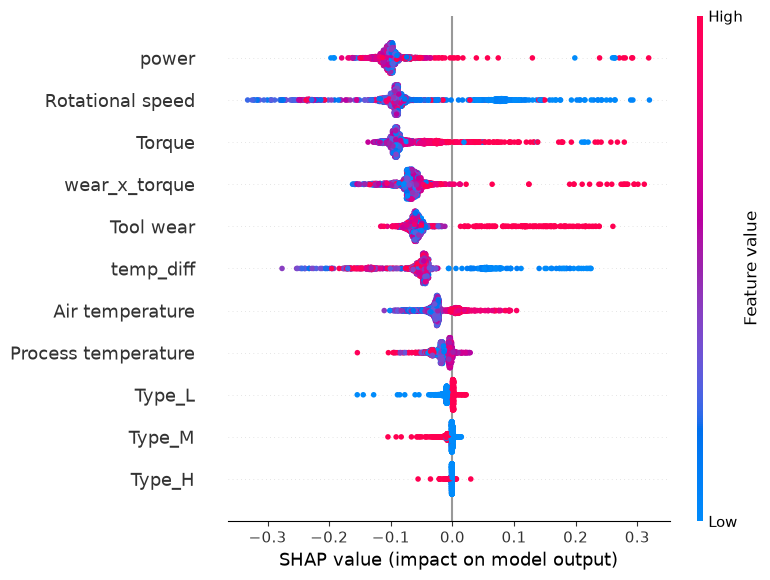

In [47]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X_test.columns
)

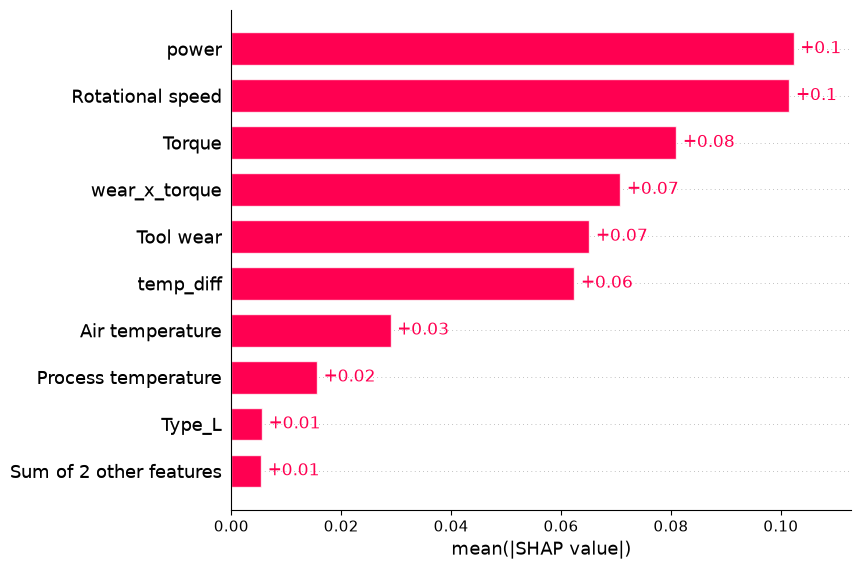

In [48]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values[:, :, 1],
        data=X_test.values,
        feature_names=X_test.columns
    )
)

In [49]:
highest_risk_index = results["Risk Score"].idxmax()

print(highest_risk_index)

1391


In [50]:
sample = X_test.loc[[highest_risk_index]]

sample

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M
1391,298.9,310.2,2737,8.8,142,11.3,24085.6,1249.6,0,1,0


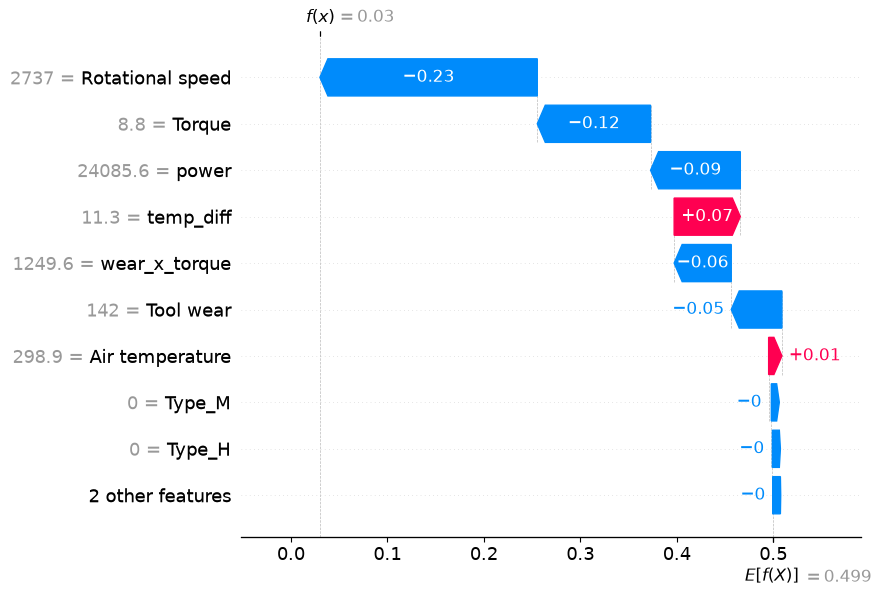

In [51]:
sample_index = highest_risk_index

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.loc[sample_index].values,
        feature_names=X_test.columns
    )
)

In [53]:
print(balanced_model.predict_proba(sample))

[[0. 1.]]


In [54]:
print(explainer.expected_value)

[0.5006225 0.4993775]


In [55]:
import joblib

joblib.dump(
    balanced_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

In [56]:
print(df.columns.tolist())

['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_diff', 'power', 'wear_x_torque']
